<a href="https://colab.research.google.com/github/denys-dias/EBAC-Curso-de-Analista-de-Dados/blob/main/Profissao_Analista_de_dados_M13_Exercicio_V02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/media/logo/newebac_logo_black_half.png" alt="ebac-logo">

---

# **Módulo** | Análise de Dados: Data Wrangling II
Caderno de **Exercícios**<br>
Professor [André Perez](https://www.linkedin.com/in/andremarcosperez/)

---

# **Tópicos**

<ol type="1">
  <li>Agregação e Ordenação;</li>
  <li>Combinação;</li>
  <li>Técnicas Avançadas.</li>
</ol>

---

# **Exercícios**

Neste exercícios, vamos trabalhar com dados geográficos, demográficos e econômicos do Brasil. Vamos manipular e combinar dados de duas frentes distintas para poder responder perguntas de negócios.

## 1\. Data Wrangling

### **1.1. Estados**

O arquivo `estados-bruto.xml` contém informações sobre estados (nome, sigla e região). **Carregue-o na máquina virtual do Google Colab**. Um arquivo do tipo XML é similar a um arquivo do tipo HTML, exemplo do estado do Acre:

```xml
<ESTADO>
  <ID>1</ID>
  <NOME>ACRE</NOME>
  <IDCAPITAL>16</IDCAPITAL>
  <SIGLA>AC</SIGLA>
  <REGIAO>NORTE</REGIAO>
</ESTADO>
```

Utilize o pacote Python `beautifulsoup4` para extrair os dados do arquivo `estados-bruto.xml` providenciado. Salve os dados extraidos no arquivo `estados-limpo.csv` separado por `;`. Exemplo das três primeiras linhas mais o cabeçalho:

```
estado;sigla;regiao
ACRE;AC;NORTE
ALAGOAS;AL;NORDESTE
AMAPA;AP;NORTE
```

**Dica**: Utilize o parser de xml chamado `lxml` do `beautifulsoup4`.

In [ ]:
# ler o arquivo estados-bruto.xml, utilize o xml parser chamado lxml

from bs4 import BeautifulSoup

NOME_ARQUIVO_FONTE = 'estados-bruto.xml'

fonte = BeautifulSoup(open(NOME_ARQUIVO_FONTE, mode = 'r'), 'lxml')

<ipython-input-2-e71258ee5343>:7: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  fonte = BeautifulSoup(open(NOME_ARQUIVO_FONTE, mode = 'r'), 'lxml')


In [ ]:
# visualize os resultados

fonte

<?xml version="1.0" encoding="utf-8" ?><html><body><estados>
<estado>
<id>1</id>
<nome>ACRE</nome>
<idcapital>16</idcapital>
<sigla>AC</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>2</id>
<nome>ALAGOAS</nome>
<idcapital>68</idcapital>
<sigla>AL</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>3</id>
<nome>AMAPA</nome>
<idcapital>131</idcapital>
<sigla>AP</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>4</id>
<nome>AMAZONAS</nome>
<idcapital>178</idcapital>
<sigla>AM</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>5</id>
<nome>BAHIA</nome>
<idcapital>536</idcapital>
<sigla>BA</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>6</id>
<nome>CEARA</nome>
<idcapital>676</idcapital>
<sigla>CE</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>7</id>
<nome>DISTRITO FEDERAL</nome>
<idcapital>916</idcapital>
<sigla>DF</sigla>
<regiao>CENTRO-OESTE</regiao>
</estado>
<estado>
<id>8</id>
<nome>ESPIRITO SANTO</nome>
<idcapital>879</idcapital>
<sigla>ES</sigla

In [ ]:
# manipule os dados
import pandas as pd #importar o pandas

es = fonte.find_all('nome') #encontrando nome do XML
sig = fonte.find_all('sigla') #encontrando sigla do XML
reg = fonte.find_all('regiao')#encontrando região do XML

conteudo_extraido = []
for i in range(len(es)): # lendo a tag estado?
  aux = [es[i].get_text(),sig[i].get_text(),reg[i].get_text()] #Extraindo os dados e adicionando a variável aux
  conteudo_extraido.append(aux)
# continue o codigo aqui

In [ ]:
# escrever o conteudo extraido no arquivo estados-limpo.csv separados por ;

NOME_ARQUIVO_DESTINO = 'estados-limpo.csv'
tabela = pd.DataFrame(conteudo_extraido,columns = ['estado','sigla','região'])
tabela.to_csv(NOME_ARQUIVO_DESTINO, index = False, sep=';')

# continue o codigo aqui

### **1.2. Cidades**

O arquivo `cidades-bruto.csv` contém informações demográficas e socioeconomicas das cidades do Brasil. **Carregue-o na máquina virtual do Google Colab**. Utilize o pacote Python `pandas` para extrair os dados do arquivo `cidades-bruto.xml` providenciado. Seguindo as seguintes especificações:

1. Apenas dados do censo de 2010;
1. Apenas as colunas UF, Nome, PIB, Pop_est_2009 e PIB_percapita.

Salve os dados extraidos no arquivo `cidades-limpo.csv` separado por `;`. Exemplo das três primeiras linhas mais o cabeçalho:

```
estado;cidade;populacao;pib;pib_percapita
BAHIA;TREMEDAL;18433;57883.9921875;3140.23999023
RIO GRANDE DO SUL;TURUÇU;4000;45723875;11430.96972656
ESPIRITO SANTO;VITÓRIA;320156;19782628;61790.58984375
```

In [ ]:
# ler o arquivo cidades-bruto.csv

import pandas as pd

NOME_ARQUIVO_FONTE = 'cidades-bruto.csv'

fonte = pd.read_csv(NOME_ARQUIVO_FONTE) # continue o codigo aqui

In [ ]:
# 1.Apenas dados do censo de 2010;
fonte[fonte['Censo'] == 2010.0]

,FID,gid,UF,nome,Censo,PIB,Pop_est_2009,PIB_percapita,Descrição,legenda,classe,geom
0,vw_pib_percapita.fid-4514e25a_17aaa325034_-258f,215,BAHIA,Tremedal,2010.0,5.788399e+04,18433,3140.239990,Produto Interno Bruto per capita,- 9639.65,1,MULTIPOLYGON (((-41.458803305191566 -14.781415...
1,vw_pib_percapita.fid-4514e25a_17aaa325034_-258e,306,RIO GRANDE DO SUL,Turuçu,2010.0,4.572388e+04,4000,11430.969727,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-52.035349932081274 -31.567509...
2,vw_pib_percapita.fid-4514e25a_17aaa325034_-258d,900,ESPIRITO SANTO,Vitória,2010.0,1.978263e+07,320156,61790.589844,Produto Interno Bruto per capita,52702.10 - 133669.00,4,MULTIPOLYGON (((-40.3292566978242 -20.23997417...
3,vw_pib_percapita.fid-4514e25a_17aaa325034_-258c,3613,MINAS GERAIS,Jacutinga,2010.0,2.478160e+05,21424,11567.209961,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-46.50528160015326 -22.3400120...
4,vw_pib_percapita.fid-4514e25a_17aaa325034_-258b,1028,PIAUÍ,Nazária,2010.0,2.095138e+04,7895,2653.750000,Produto Interno Bruto per capita,- 9639.65,1,POLYGON ((-42.826685407155495 -5.3480291684437...
...,...,...,...,...,...,...,...,...,...,...,...,...
5561,vw_pib_percapita.fid-4514e25a_17aaa325034_-eba,5254,SANTA CATARINA,Campo Erê,2010.0,1.876289e+05,9737,19269.679688,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-53.024131281087385 -26.361357...
5562,vw_pib_percapita.fid-4514e25a_17aaa325034_-eb9,2749,PARANÁ,Planalto,2010.0,1.385535e+05,13983,9908.709961,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-53.61882711231503 -25.6460599...
5563,vw_pib_percapita.fid-4514e25a_17aaa325034_-eb8,3779,SÃO PAULO,Guararapes,2010.0,5.320191e+05,29639,17949.970703,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-50.70271677275949 -21.0257124...
5564,vw_pib_percapita.fid-4514e25a_17aaa325034_-eb7,617,RIO GRANDE DO SUL,Barra do Guarita,2010.0,2.198064e+04,3067,7166.819824,Produto Interno Bruto per capita,- 9639.65,1,MULTIPOLYGON (((-53.778785810369236 -27.152703...


In [ ]:
# 2.Apenas as colunas UF, Nome, PIB, Pop_est_2009 e PIB_percapita.

fonte[['UF','nome','PIB','Pop_est_2009','PIB_percapita']]

,UF,nome,PIB,Pop_est_2009,PIB_percapita
0,BAHIA,Tremedal,5.788399e+04,18433,3140.239990
1,RIO GRANDE DO SUL,Turuçu,4.572388e+04,4000,11430.969727
2,ESPIRITO SANTO,Vitória,1.978263e+07,320156,61790.589844
3,MINAS GERAIS,Jacutinga,2.478160e+05,21424,11567.209961
4,PIAUÍ,Nazária,2.095138e+04,7895,2653.750000
...,...,...,...,...,...
5561,SANTA CATARINA,Campo Erê,1.876289e+05,9737,19269.679688
5562,PARANÁ,Planalto,1.385535e+05,13983,9908.709961
5563,SÃO PAULO,Guararapes,5.320191e+05,29639,17949.970703
5564,RIO GRANDE DO SUL,Barra do Guarita,2.198064e+04,3067,7166.819824


In [ ]:
# escrever o conteudo extraido no arquivo cidades-limpo.csv separados por ;

NOME_ARQUIVO_DESTINO = 'cidades-limpo.csv'

# continue o codigo aqui
fonte[['UF','nome','PIB','Pop_est_2009','PIB_percapita']].to_csv(NOME_ARQUIVO_DESTINO, index = False, sep=';')

### **1.3. Brasil**

Utilize o pacote Python `pandas` para combinar os dados do arquivo `estados-limpo.csv` com os dados do arquivo `cidades-limpo.csv` em um único dataframe. Escolha a coluna e o método de combinação de tal forma que **não haja perda de dados** no processo (não produzirá valores nulos `NaN`). Salve os dados do dataframe no arquivo `brasil.csv`

In [ ]:
# solução do exercício 1.3
def corrigir_nomes(nome):
    nome = nome.replace('Ã', 'A').replace('Á', 'A').replace('Í','I').replace('Ô','O')
    return nome
estados_df = pd.read_csv('estados-limpo.csv', sep =';')
cidades_df = pd.read_csv('cidades-limpo.csv', sep =';')
cidades_df['UF'] = cidades_df['UF'].apply(corrigir_nomes)
#print(estados_df)
#print(cidades_df)
Brasil_df = pd.merge(estados_df, cidades_df, left_on='estado', right_on='UF', how='outer')
#print(Brasil_df)
Brasil_df.to_csv('brasil.csv', index='false', sep=';')
#

---

## 2\. Data Analytics

### **2.1. DataFrame**

Utilize o pacote Python `pandas` para carregar o arquivo `brasil.csv` no dataframe `brasil_df`.

In [ ]:
# solução do exercício 2.1
brasil_df = pd.read_csv('brasil.csv', sep=';')
brasil_df

,Unnamed: 0,estado,sigla,região,UF,nome,PIB,Pop_est_2009,PIB_percapita
0,0,ACRE,AC,NORTE,ACRE,Marechal Thaumaturgo,1.091819e+05,14275,7648.470215
1,1,ACRE,AC,NORTE,ACRE,Senador Guiomard,2.171539e+05,19697,11024.719727
2,2,ACRE,AC,NORTE,ACRE,Assis Brasil,4.834730e+04,5662,8538.910156
3,3,ACRE,AC,NORTE,ACRE,Epitaciolândia,1.296411e+05,14224,9114.250000
4,4,ACRE,AC,NORTE,ACRE,Manoel Urbano,6.147873e+04,7505,8191.700195
...,...,...,...,...,...,...,...,...,...
5561,5561,MINAS GERAIS,MG,SUDESTE,MINAS GERAIS,Nacip Raydan,1.600776e+04,3015,5309.370117
5562,5562,MINAS GERAIS,MG,SUDESTE,MINAS GERAIS,Nova Ponte,4.681494e+05,12504,37439.968750
5563,5563,MINAS GERAIS,MG,SUDESTE,MINAS GERAIS,São Gonçalo do Sapucaí,2.886858e+05,23627,12218.469727
5564,5564,MINAS GERAIS,MG,SUDESTE,MINAS GERAIS,Barbacena,1.335420e+06,128572,10386.549805


### **2.2. Analise**

Utilize o dataframe `brasil_df` para responder as seguintes perguntas de negócio:

 - Quais são as 10 cidades mais populosas do Brasil?

In [ ]:
# código para responder a pergunta
brasil_df.sort_values(by='Pop_est_2009', ascending=False).head(10)

,Unnamed: 0,estado,sigla,região,UF,nome,PIB,Pop_est_2009,PIB_percapita
4414,4414,SAO PAULO,SP,SUDESTE,SAO PAULO,São Paulo,389317152.0,11037593,35271.929688
2755,2755,RIO DE JANEIRO,RJ,SUDESTE,RIO DE JANEIRO,Rio de Janeiro,175739344.0,6186710,28405.949219
246,246,BAHIA,BA,NORDESTE,BAHIA,Salvador,32824228.0,2998056,10948.500000
803,803,DISTRITO FEDERAL,DF,CENTRO-OESTE,DISTRITO FEDERAL,Brasília,131487264.0,2606885,50438.460938
767,767,CEARA,CE,NORDESTE,CEARA,Fortaleza,31789186.0,2505552,12687.500000
5458,5458,MINAS GERAIS,MG,SUDESTE,MINAS GERAIS,Belo Horizonte,44595204.0,2452617,18182.699219
2061,2061,PARANA,PR,SUL,PARANA,Curitiba,45762420.0,1851215,24720.210938
142,142,AMAZONAS,AM,NORTE,AMAZONAS,Manaus,40486108.0,1738641,23286.060547
2454,2454,PERNAMBUCO,PE,NORDESTE,PERNAMBUCO,Recife,24835340.0,1561659,15903.179688
1692,1692,PARA,PA,NORTE,PARA,Belém,16526989.0,1437600,11496.240234


 - Quais são as 5 cidades com a menor PIB per capita da região nordeste?

In [ ]:
# código para responder a pergunta
brasil_df[brasil_df['região'] == 'NORDESTE'].sort_values(by='PIB_percapita', ascending=True).head(5)

,Unnamed: 0,estado,sigla,região,UF,nome,PIB,Pop_est_2009,PIB_percapita
1320,1320,MARANHAO,MA,NORDESTE,MARANHAO,São Vicente Ferrer,39492.960938,20463,1929.969971
1215,1215,MARANHAO,MA,NORDESTE,MARANHAO,Cajapió,22781.035156,10337,2203.830078
271,271,BAHIA,BA,NORDESTE,BAHIA,Lamarão,30241.320312,12995,2327.149902
2520,2520,PIAUI,PI,NORDESTE,PIAUI,Dom Inocêncio,25457.230469,10795,2358.239990
1340,1340,MARANHAO,MA,NORDESTE,MARANHAO,Timbiras,63724.851562,26909,2368.159912


 - Quais são as 15 cidades com maior PIB do do estado de São Paulo?

In [ ]:
# código para responder a pergunta
brasil_df[brasil_df['UF'] == 'SAO PAULO'].sort_values(by='PIB', ascending= False,).head(15)

,Unnamed: 0,estado,sigla,região,UF,nome,PIB,Pop_est_2009,PIB_percapita
4414,4414,SAO PAULO,SP,SUDESTE,SAO PAULO,São Paulo,389317152.0,11037593,35271.929688
4366,4366,SAO PAULO,SP,SUDESTE,SAO PAULO,Guarulhos,32473828.0,1299283,24993.650391
4483,4483,SAO PAULO,SP,SUDESTE,SAO PAULO,Campinas,31654720.0,1064669,29731.980469
4248,4248,SAO PAULO,SP,SUDESTE,SAO PAULO,Osasco,31616452.0,718646,43994.468750
3951,3951,SAO PAULO,SP,SUDESTE,SAO PAULO,São Bernardo do Campo,28935768.0,810979,35680.050781
4487,4487,SAO PAULO,SP,SUDESTE,SAO PAULO,Barueri,26908070.0,270173,99595.703125
3908,3908,SAO PAULO,SP,SUDESTE,SAO PAULO,Santos,22546134.0,417098,54054.761719
4135,4135,SAO PAULO,SP,SUDESTE,SAO PAULO,São José dos Campos,22018042.0,615871,35751.058594
4155,4155,SAO PAULO,SP,SUDESTE,SAO PAULO,Jundiaí,16585137.0,349929,47395.718750
3957,3957,SAO PAULO,SP,SUDESTE,SAO PAULO,Santo André,14709603.0,673396,21843.910156


 - Qual é o PIB do estado de Santa Catarina?

In [ ]:
# código para responder a pergunta
df = brasil_df[brasil_df['UF'] == 'SANTA CATARINA'].loc[:,['PIB','estado']]
df.groupby(df['estado'])['PIB'].agg(['sum'])

,sum
estado,
SANTA CATARINA,1.298063e+08


 - Qual é o população da região sul?

In [ ]:
# código para responder a pergunta
brasil_df[brasil_df['região'] == 'SUL'].loc[:,'Pop_est_2009'].sum()

27719118

 - Qual é o PIB per capito médio das cidades do Mato Grosso do Sul?

In [ ]:
# código para responder a pergunta
df = brasil_df[brasil_df['UF'] == 'MATO GROSSO DO SUL'].loc[:,['PIB_percapita','estado']]
df.groupby(df['estado'])['PIB_percapita'].agg(['mean'])

,mean
estado,
MATO GROSSO DO SUL,14458.89686


 - Qual é a população do Brasil?

In [ ]:
# código para responder a pergunta
total = brasil_df.loc[:,['Pop_est_2009']].sum()
total

,0
Pop_est_2009,191501418


### **2.3. Visualização**

Utilize o dataframe `brasil_df` para gerar as seguintes visualizações.

 - Gere um gráfico de barras com as 10 cidades menos populosas do Brasil.

<Axes: xlabel='estado'>

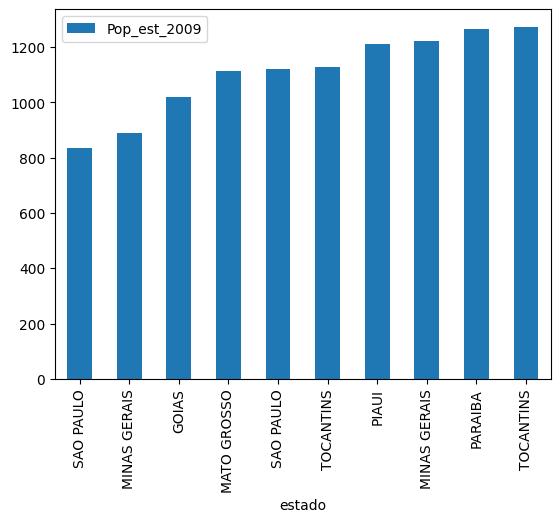

In [ ]:
# código para gerar a visualização
import matplotlib.pyplot as plt

df_aux = brasil_df.loc[brasil_df['estado']!=' ']
df_aux = df_aux.nsmallest(10, 'Pop_est_2009')
df_aux.plot(kind='bar', x='estado', y='Pop_est_2009')

 - Gere um gráfico de pizza com a proporção da população do Brasil por região.

<Axes: ylabel='sum'>

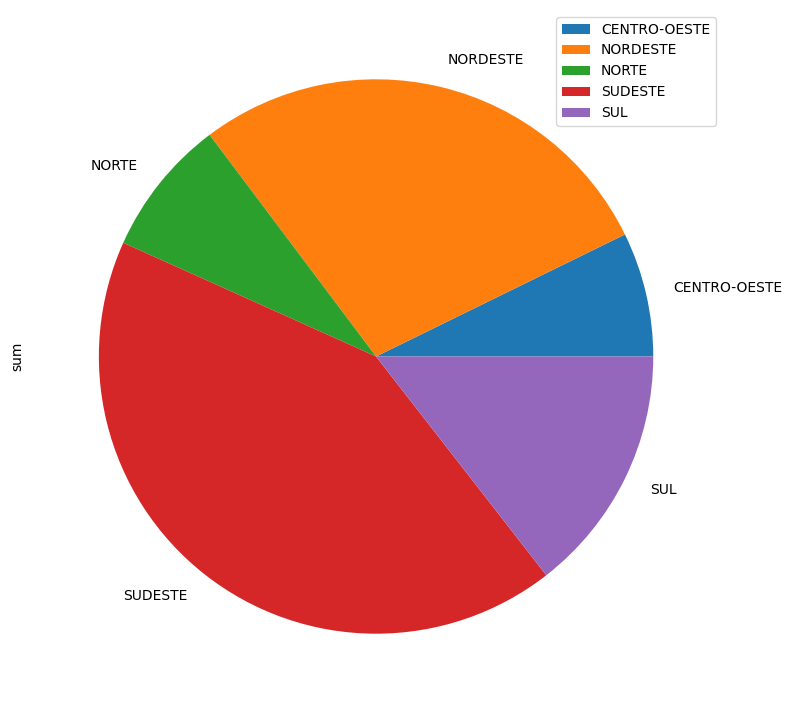

In [85]:
# código para gerar a visualização
df_aux = brasil_df.loc[brasil_df['região']!=' ']
df_aux = df_aux.groupby(['região'])['Pop_est_2009'].agg(['sum'])
df_aux.plot.pie(y='sum',figsize=(11,9))